# Quantum Measurement Simulation with Mixture States

This notebook simulates quantum measurement processes with intermediate projective measurements. The system consists of:
- **Input cavity mode**: Stores incoming photons
- **Output cavity mode**: Stores outgoing photons  
- **Qubit**: Two-level system that can be measured and rotated

## Physical System Overview
The simulation models a quantum optics setup where:
1. Photons enter through an input cavity mode
2. They interact with a qubit through dispersive coupling
3. The qubit undergoes rotations and measurements at specific time intervals
4. The system evolution is tracked through density matrices

Time interval analysis with intermediate measurements:
Time	Measurement Probability
-----------------------------------
5.00	1.000


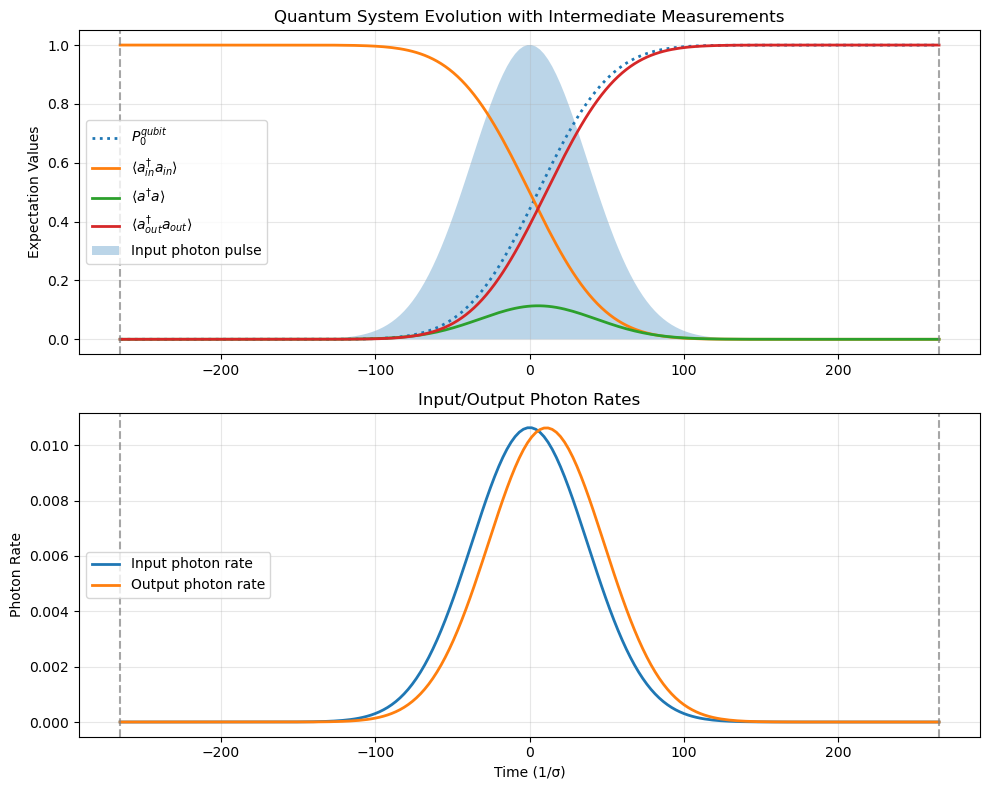


Simulation completed successfully!
Total measurement probabilities: [0.9997009359985786]


In [3]:
# QUANTUM MEASUREMENT SIMULATION WITH MIXTURE STATES

import numpy as np
from qutip import *
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot
from numpy import pi, sqrt, linspace, exp, sin, cos, abs, angle, log, max, real
from scipy.special import erf, erfc
from scipy.integrate import cumulative_trapezoid
from math import atan2

# ==================== PHYSICAL PARAMETERS ====================
k = 3.0e-2 * 2 * pi      # photon-cavity coupling strength
sigma = 0.1 * k          # inverse of pulse width (sigma = 2*sqrt(log(2))/t_pulse)
chi = 0.5 * k            # dispersive coupling strength
args = {'gm': k, 'sigma': sigma, 'chi': chi}

# ==================== SYSTEM DIMENSIONS ====================
nlev = 2                 # number of levels for cavity modes
nqubit = 2              # number of qubit levels (always 2 for qubits)

# ==================== BASIC OPERATORS ====================
I2 = identity(2)         # 2x2 identity matrix
In = identity(nlev)      # nlev x nlev identity matrix
An = destroy(nlev)       # annihilation operator for cavity
Acn = create(nlev)       # creation operator for cavity

# Pauli operators for qubit
Sz = sigmaz()           # σz Pauli operator
Sx = sigmax()           # σx Pauli operator

# Rotation and projection operators
Rx = Qobj([[1, -1], [1, 1]]) / sqrt(2)    # π/2 rotation around x-axis
P0 = Qobj([[1, 0], [0, 0]])               # projection onto |0⟩
P1 = Qobj([[0, 0], [0, 1]])               # projection onto |1⟩

def d(operator):
    """
    Compute the Hermitian conjugate (dagger) of an operator.
    
    Args:
        operator: QuTiP Qobj operator
        
    Returns:
        QuTiP Qobj: Hermitian conjugate of the input operator
    """
    return operator.dag()

# ==================== COMPOSITE SYSTEM OPERATORS ====================
# System structure: input_cavity ⊗ output_cavity ⊗ qubit

# Input cavity operators
ain = tensor(An, In, I2)        # input cavity annihilation
ainc = d(ain)                   # input cavity creation

# Output cavity operators  
a = tensor(In, An, I2)          # output cavity annihilation
ac = d(a)                       # output cavity creation

# Qubit operators in composite space
sz1 = tensor(In, In, Sz)        # σz for qubit in composite system
sx1 = tensor(In, In, Sx)        # σx for qubit in composite system

# Measurement and rotation operators in composite space
r = tensor(In, In, Rx)          # rotation operator in composite space
p0 = tensor(In, In, P0)         # projection onto |0⟩ in composite space
p1 = tensor(In, In, P1)         # projection onto |1⟩ in composite space

def rot(rho, direction=0):
    """
    Apply rotation to the qubit state.
    
    This function applies a π/2 rotation around the x-axis to the qubit,
    which is useful for changing measurement basis.
    
    Args:
        rho: QuTiP Qobj density matrix
        direction: int, 0 for forward rotation, 1 for backward rotation
        
    Returns:
        QuTiP Qobj: Rotated density matrix
    """
    if direction == 0:
        return r * rho * r.dag()
    else:
        return r.dag() * rho * r

def proj(rho, state):
    """
    Project density matrix onto a specific qubit state.
    
    This function performs a projective measurement on the qubit,
    collapsing the state to either |0⟩ or |1⟩.
    
    Args:
        rho: QuTiP Qobj density matrix
        state: int, 0 for |0⟩ state, 1 for |1⟩ state
        
    Returns:
        QuTiP Qobj: Projected density matrix (unnormalized)
    """
    if state == 0:
        p = p0
    else:
        p = p1
    return p * rho * p.dag()

def gu(t, args):
    """
    Time-dependent coupling function for input pulse.
    
    This function describes the temporal profile of the input pulse,
    using a Gaussian-like shape with error function normalization.
    
    Args:
        t: float, time parameter
        args: dict, contains 'sigma' parameter
        
    Returns:
        float: Coupling strength at time t
    """
    sigma = args['sigma']
    dx = sigma * t
    out = sqrt(2 * sigma / sqrt(pi) * exp(-dx**2) / erfc(dx))
    return float(out)

def bout(t, args):
    """
    Output field operator as function of time.
    
    This operator describes the output field from the cavity,
    combining the direct cavity output with the input coupling.
    
    Args:
        t: float, time parameter
        args: dict, contains 'gm' parameter
        
    Returns:
        QuTiP Qobj: Output field operator
    """
    gm = args['gm']
    return sqrt(gm) * a + gu(t, args) * ain

def sim(args, rho0, t1, t2):
    """
    Simulate quantum evolution between two time points.
    
    This function evolves the system using the master equation with
    time-dependent Hamiltonian and Lindblad operators.
    
    Args:
        args: dict, system parameters
        rho0: QuTiP Qobj, initial density matrix
        t1: float, initial time
        t2: float, final time
        
    Returns:
        tuple: (time_array, density_matrices_array)
    """
    gm = args['gm']
    chi = args['chi']
    
    # Hamiltonian components
    Hc = 1j / 2 * sqrt(gm) * (ainc * a - ain * ac)   # cavity-cavity coupling
    Hq = -chi * ac * a * sz1                          # dispersive qubit-cavity coupling
    
    # Time-dependent Hamiltonian
    H = [Hq, [Hc, gu]]
    
    # Lindblad operators for decay/decoherence
    L = [lambda t, args: bout(t, args)]
    
    # Time evolution
    t_ = linspace(t1, t2, 200)
    rho_ = mesolve(H, rho0, t_, L, args=args).states
    
    return t_, rho_

# ==================== INITIAL CONDITIONS ====================
# Initial state: |1⟩_input ⊗ |0⟩_output ⊗ |0⟩_qubit
psi0 = tensor(basis(nlev, 1), basis(nlev, 0), basis(2, 0))
rho0 = psi0 * psi0.dag()

# ==================== SIMULATION TIME INTERVALS ====================
# Time intervals for measurements (normalized by 1/sigma)
tint = np.array([-5, 5]) / sigma
# Alternative time intervals (commented out):
# tint = np.array([-5, -1.5, -0.5, 0.5, 1.5, 5]) / sigma
# tint = np.array([-5, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 5]) / sigma

# ==================== MAIN SIMULATION LOOP ====================
t_ = []                     # combined time array
rho_ = []                   # combined density matrix array
prob = []                   # measurement probabilities

print("Time interval analysis with intermediate measurements:")
print("Time\tMeasurement Probability")
print("-" * 35)

for kt, t in enumerate(tint[:-1]):
    t1 = tint[kt]
    t2 = tint[kt + 1]
    
    # Apply rotation before evolution
    rho0 = rot(rho0, 0)
    
    # Evolve system in current time interval
    tp_, rhop_ = sim(args, rho0, t1, t2)
    
    # Apply rotation after evolution
    rho0 = rot(rhop_[-1], 1)
    
    # Measure and display probability
    measurement_prob = 1 - proj(rho0, 0).tr()
    print(f"{t2*sigma:.2f}\t{measurement_prob:.3f}")
    
    # Project onto |0⟩ state (measurement outcome)
    rho0 = proj(rho0, 0)
    
    # Store results
    t_ = np.concatenate((t_, tp_))
    rho_ = np.concatenate((rho_, rhop_))
    prob.append(measurement_prob)

# ==================== OBSERVABLES CALCULATION ====================
# Calculate input and output photon statistics
b2in_ = [gu(t_[kr], args)**2 * expect(ainc * ain, rho) for kr, rho in enumerate(rho_)]
b2out_ = [expect(d(bout(t_[kr], args)) * bout(t_[kr], args), rho) for kr, rho in enumerate(rho_)]
nout_ = cumulative_trapezoid(b2out_, t_, initial=0)

# ==================== PLOTTING RESULTS ====================
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot 1: System observables vs time
ax1.plot(t_, [(1 - expect(sx1, rho)) / 2 for rho in rho_], ':', 
         label=r'$P_0^{qubit}$', linewidth=2)
ax1.plot(t_, [expect(ainc * ain, rho) for rho in rho_], 
         label=r'$\langle a_{in}^{\dag} a_{in} \rangle$', linewidth=2)
ax1.plot(t_, [expect(ac * a, rho) for rho in rho_], 
         label=r'$\langle a^{\dag} a \rangle$', linewidth=2)
ax1.plot(t_, nout_, label=r'$\langle a_{out}^{\dag} a_{out} \rangle$', linewidth=2)
ax1.fill(t_, b2in_ / max(b2in_), alpha=0.3, label='Input photon pulse')

# Mark measurement times
for t in tint:
    ax1.axvline(x=t, color='gray', linestyle='--', alpha=0.7)

ax1.legend(loc="center left")
ax1.set_ylabel('Expectation Values')
ax1.set_title('Quantum System Evolution with Intermediate Measurements')
ax1.grid(True, alpha=0.3)

# Plot 2: Input and output photon rates
ax2.plot(t_, b2in_, label='Input photon rate', linewidth=2)
ax2.plot(t_, b2out_, label='Output photon rate', linewidth=2)

# Mark measurement times
for t in tint:
    ax2.axvline(x=t, color='gray', linestyle='--', alpha=0.7)

ax2.legend(loc="center left")
ax2.set_xlabel('Time (1/σ)')
ax2.set_ylabel('Photon Rate')
ax2.set_title('Input/Output Photon Rates')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSimulation completed successfully!")
print(f"Total measurement probabilities: {prob}")


# Simulation with All Possible Measurement Outcomes

This section explores all possible measurement sequences and their corresponding probabilities. The simulation:

1. **Generates all possible measurement sequences**: Each sequence is represented as a binary string where 0 = |0⟩ outcome and 1 = |1⟩ outcome
2. **Calculates probabilities**: For each sequence, computes the probability of that particular measurement outcome
3. **Visualizes results**: Shows the evolution for each possible measurement sequence
4. **Statistical analysis**: Computes cumulative probabilities for detecting at least N photons

## Key Features:
- **Exhaustive enumeration**: All 2^N possible measurement sequences
- **Branching quantum trajectories**: Each measurement outcome leads to a different evolution path
- **Probability tracking**: Real-time calculation of measurement probabilities
- **Visual comparison**: Side-by-side plots of different measurement sequences

Analyzing 32 possible measurement sequences
Each sequence has 5 measurements
Time intervals: [-212.20659079 -106.10329539  -53.0516477     0.           53.0516477
  106.10329539]

Processing sequences...
Processed 8/32 sequences
Processed 8/32 sequences
Processed 16/32 sequences
Processed 16/32 sequences
Processed 24/32 sequences
Processed 24/32 sequences
Processed 32/32 sequences
Processed 32/32 sequences


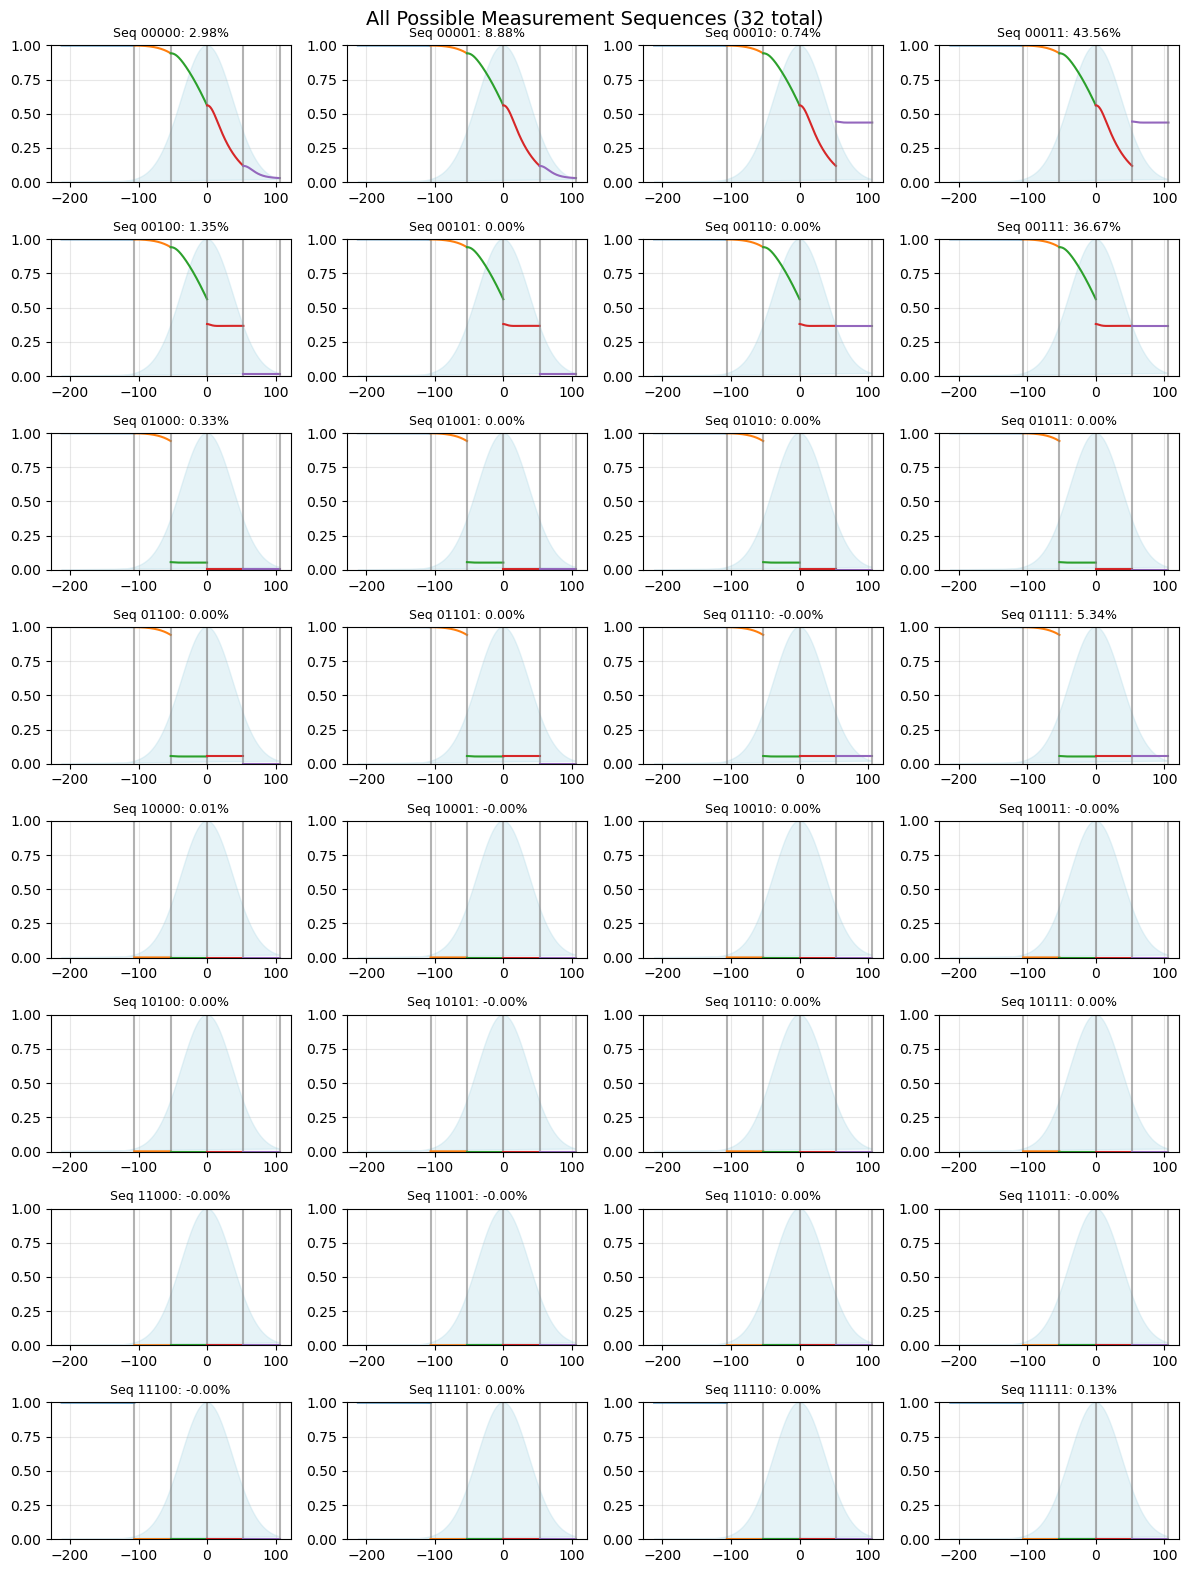


Simulation completed!
All 32 measurement sequences analyzed successfully.


In [2]:
# COMPREHENSIVE SIMULATION: ALL POSSIBLE MEASUREMENT SEQUENCES

import numpy as np
from qutip import *
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot
from numpy import pi, sqrt, linspace, exp, sin, cos, abs, angle, log, max, real
from scipy.special import erf, erfc
from scipy.integrate import cumulative_trapezoid
from math import atan2

# ==================== PHYSICAL PARAMETERS ====================
k = 3.0e-2 * 2 * pi      # photon-cavity coupling strength  
sigma = 0.1 * k          # inverse of pulse width
chi = 0.5 * k            # dispersive coupling strength
args = {'gm': k, 'sigma': sigma, 'chi': chi}

# ==================== SYSTEM DIMENSIONS ====================
nlev = 2                 # number of levels for cavity modes
nqubit = 2              # number of qubit levels

# ==================== QUANTUM OPERATORS ====================
I2 = identity(2)         # 2x2 identity matrix
In = identity(nlev)      # nlev x nlev identity matrix
An = destroy(nlev)       # annihilation operator
Acn = create(nlev)       # creation operator

# Pauli operators
Sz = sigmaz()           # σz Pauli operator
Sx = sigmax()           # σx Pauli operator

# Rotation operators
Rx = Qobj([[1, -1], [1, 1]]) / sqrt(2)      # π/2 rotation around x-axis
Ry = Qobj([[1, -1j], [-1j, 1]]) / sqrt(2)   # π/2 rotation around y-axis

# Projection operators
P0 = Qobj([[1, 0], [0, 0]])                 # projection onto |0⟩
P1 = Qobj([[0, 0], [0, 1]])                 # projection onto |1⟩

def d(operator):
    """
    Hermitian conjugate (dagger) of an operator.
    
    Args:
        operator: QuTiP Qobj
        
    Returns:
        QuTiP Qobj: Hermitian conjugate
    """
    return operator.dag()

# ==================== COMPOSITE SYSTEM OPERATORS ====================
# System: input_cavity ⊗ output_cavity ⊗ qubit

# Input cavity operators
ain = tensor(An, In, I2)        # input cavity annihilation
ainc = d(ain)                   # input cavity creation

# Output cavity operators
a = tensor(In, An, I2)          # output cavity annihilation  
ac = d(a)                       # output cavity creation

# Qubit operators in composite space
sz1 = tensor(In, In, Sz)        # σz in composite system
sx1 = tensor(In, In, Sx)        # σx in composite system

# Rotation and projection operators in composite space
r = tensor(In, In, Rx)          # rotation operator
p = [tensor(In, In, P0), tensor(In, In, P1)]  # projection operators array

def rot0(rho, direction=0):
    """
    Single rotation operation on density matrix.
    
    Args:
        rho: QuTiP Qobj density matrix
        direction: int, 0 for forward, 1 for backward rotation
        
    Returns:
        QuTiP Qobj: Rotated density matrix
    """
    if direction == 0:
        return r * rho * r.dag()
    else:
        return r.dag() * rho * r

def rot(rho, direction=0):
    """
    Rotation operation - handles both single matrices and arrays.
    
    This function applies π/2 rotations around the x-axis to change
    the measurement basis of the qubit.
    
    Args:
        rho: QuTiP Qobj or array of density matrices
        direction: int, 0 for forward, 1 for backward rotation
        
    Returns:
        QuTiP Qobj or array: Rotated density matrix/matrices
    """
    if isinstance(rho, (list, np.ndarray)):
        return [rot0(rhoin, direction) for rhoin in rho]
    else:
        return rot0(rho, direction)

def proj(rho, state):
    """
    Projection operation - handles both single matrices and arrays.
    
    Performs projective measurement on the qubit, collapsing it to
    either |0⟩ or |1⟩ state.
    
    Args:
        rho: QuTiP Qobj or array of density matrices
        state: int, 0 for |0⟩, 1 for |1⟩
        
    Returns:
        QuTiP Qobj or array: Projected density matrix/matrices (unnormalized)
    """
    if isinstance(rho, (list, np.ndarray)):
        return [p[state] * rhoin * p[state].dag() for rhoin in rho]
    else:
        return p[state] * rho * p[state].dag()

def meas(rho, state):
    """
    Measurement probability calculation.
    
    Computes the probability of measuring the qubit in state |0⟩ or |1⟩.
    
    Args:
        rho: QuTiP Qobj or array of density matrices
        state: int, 0 for |0⟩, 1 for |1⟩
        
    Returns:
        float or array: Measurement probability/probabilities
    """
    if isinstance(rho, (list, np.ndarray)):
        return [(p[state] * rhoin * p[state].dag()).tr() for rhoin in rho]
    else:
        return (p[state] * rho * p[state].dag()).tr()

def u0(t, args):
    """
    Normalized Gaussian pulse shape.
    
    Simple Gaussian function for visualizing the input pulse envelope.
    
    Args:
        t: float or array, time parameter(s)
        args: dict, contains 'sigma' parameter
        
    Returns:
        float or array: Pulse amplitude at time t
    """
    sigma = args['sigma']
    dx = sigma * t
    if isinstance(dx, (list, np.ndarray)):
        return [float(exp(-dx0**2)) for dx0 in dx]
    else:
        return float(exp(-dx**2))

def gu(t, args):
    """
    Time-dependent coupling function for input pulse.
    
    Describes the temporal profile of the input pulse using a
    Gaussian shape with error function normalization.
    
    Args:
        t: float, time parameter
        args: dict, contains 'sigma' parameter
        
    Returns:
        float: Coupling strength at time t
    """
    sigma = args['sigma']
    dx = sigma * t
    out = sqrt(2 * sigma / sqrt(pi) * exp(-dx**2) / erfc(dx))
    return float(out)

def bout(t, args):
    """
    Output field operator as function of time.
    
    Args:
        t: float, time parameter
        args: dict, contains 'gm' parameter
        
    Returns:
        QuTiP Qobj: Output field operator
    """
    gm = args['gm']
    return sqrt(gm) * a + gu(t, args) * ain

def sim(args, rho0, t1, t2):
    """
    Quantum evolution simulation between time points.
    
    Evolves the system using the master equation with time-dependent
    Hamiltonian and Lindblad operators.
    
    Args:
        args: dict, system parameters
        rho0: QuTiP Qobj, initial density matrix
        t1: float, initial time
        t2: float, final time
        
    Returns:
        tuple: (time_array, density_matrices_array)
    """
    gm = args['gm']
    chi = args['chi']
    
    # Hamiltonian components
    Hc = 1j / 2 * sqrt(gm) * (ainc * a - ain * ac)   # cavity-cavity coupling
    Hq = -chi * ac * a * sz1                          # dispersive coupling
    
    # Time-dependent Hamiltonian
    H = [Hq, [Hc, gu]]
    
    # Lindblad operators
    L = [lambda t, args: bout(t, args)]
    
    # Evolution
    t_ = linspace(t1, t2, 200)
    rho_ = mesolve(H, rho0, t_, L, args=args).states
    
    return t_, rho_

# ==================== INITIAL CONDITIONS ====================
# Initial pure state: |1⟩_input ⊗ |0⟩_output ⊗ |0⟩_qubit
psi0 = tensor(basis(nlev, 1), basis(nlev, 0), basis(2, 0))

# ==================== MEASUREMENT TIME INTERVALS ====================
# Time intervals for sequential measurements (normalized by 1/sigma)
tint = np.array([-4, -2, -1, 0, 1, 2]) / sigma

# Alternative time sequences for different measurement strategies:
# tint = np.array([-5, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 5]) / sigma  # Many measurements
# tint = np.array([-5, -1.5, -0.5, 0.5, 1.5, 5]) / sigma            # Moderate measurements  
# tint = np.array([-5, -1, 0, 1, 5]) / sigma                         # Few measurements
# tint = np.array([-5, -0.5, 0.5, 5]) / sigma                        # Minimal measurements
# tint = np.array([-5, 0, 5]) / sigma                                # Two measurements
# tint = np.array([-5, 5]) / sigma                                   # No intermediate measurements

# ==================== SIMULATION PARAMETERS ====================
nmeas = len(tint) - 1                    # number of measurement intervals
total_sequences = 2**nmeas               # total number of possible measurement sequences
measurement_sequences = np.arange(0, total_sequences, 1)  # all possible sequences (0 to 2^nmeas - 1)
sequence_probabilities = []             # store final probabilities for each sequence

# ==================== VISUALIZATION SETUP ====================
# Create subplot grid to show all possible measurement sequences
rows = int(total_sequences / 4)
cols = 4
fig, ax = plt.subplots(rows, cols, figsize=(12, rows * 2))

print(f"Analyzing {total_sequences} possible measurement sequences")
print(f"Each sequence has {nmeas} measurements")
print(f"Time intervals: {tint}")
print("\nProcessing sequences...")

# ==================== MAIN SIMULATION LOOP ====================
# Loop through all possible measurement sequences
for sequence_idx in measurement_sequences:
    # Initialize arrays for this sequence
    t_combined = []
    rho_combined = []
    measurement_probs = []
    
    # Start with initial pure state
    rho0 = psi0 * psi0.dag()
    
    # Convert sequence index to binary string (measurement outcomes)
    binary_str = format(sequence_idx, f'0{nmeas}b')
    measurement_outcomes = [int(bit) for bit in binary_str]
    
    # Process each time interval with corresponding measurement outcome
    for time_idx, current_time in enumerate(tint[:-1]):
        t1 = tint[time_idx]
        t2 = tint[time_idx + 1]
        
        # Apply π/2 rotation before evolution
        rho0 = rot(rho0, 0)
        
        # Evolve system in current time interval
        tp_, rhop_ = sim(args, rho0, t1, t2)
        
        # Apply -π/2 rotation after evolution  
        rho0 = rot(rhop_[-1], 1)
        
        # Project onto measurement outcome for this time interval
        rho0 = proj(rho0, measurement_outcomes[time_idx])
        
        # Plot measurement probability evolution for this interval
        subplot_row = sequence_idx // 4
        subplot_col = sequence_idx % 4
        
        if time_idx == 0:
            # First interval: plot |0⟩ probability
            prob_evolution = meas(rot(rhop_, 1), 0)
        else:
            # Subsequent intervals: plot probability corresponding to previous measurement
            prob_evolution = meas(rot(rhop_, 1), measurement_outcomes[time_idx - 1])
        
        ax[subplot_row, subplot_col].plot(tp_, prob_evolution, linewidth=1.5)
        ax[subplot_row, subplot_col].axvline(x=t2, color='gray', linestyle='-', alpha=0.6)
        
        # Store combined results
        t_combined = np.concatenate((t_combined, tp_))
        rho_combined = np.concatenate((rho_combined, rhop_))
        measurement_probs.append(1 - proj(rho0, 0).tr())
    
    # Add input pulse visualization
    ax[subplot_row, subplot_col].fill(t_combined, u0(t_combined, args), 
                                      alpha=0.3, color='lightblue')
    
    # Calculate final measurement probability
    final_prob = meas(rho0, measurement_outcomes[-1])
    
    # Set subplot title with sequence and probability
    ax[subplot_row, subplot_col].set_title(f"Seq {binary_str}: {100*final_prob:.2f}%", 
                                           fontsize=9)
    ax[subplot_row, subplot_col].set_ylim(0, 1)
    ax[subplot_row, subplot_col].grid(True, alpha=0.3)
    
    # Store final probability
    sequence_probabilities.append(final_prob)
    
    # Progress indicator
    if (sequence_idx + 1) % 8 == 0:
        print(f"Processed {sequence_idx + 1}/{total_sequences} sequences")

# ==================== FINALIZE VISUALIZATION ====================
plt.suptitle(f'All Possible Measurement Sequences ({total_sequences} total)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nSimulation completed!")
print(f"All {total_sequences} measurement sequences analyzed successfully.")

STATISTICAL ANALYSIS OF MEASUREMENT SEQUENCES

Measurement Statistics:
Total number of sequences: 32
Number of measurement intervals: 5
Time intervals: ['-212.21', '-106.10', '-53.05', '0.00', '53.05', '106.10']

Probability Distribution:
Number of |1⟩ measurements	Probability
---------------------------------------------
           0           	    2.98%
           1           	   11.32%
           2           	   43.56%
           3           	   36.67%
           4           	    5.34%
           5           	    0.13%

Cumulative Probabilities:
At least N |1⟩ measurements	Probability
---------------------------------------------
     None (all |0⟩)     	    2.98%
           1            	   97.02%
           2            	   85.71%
           3            	   42.14%
           4            	    5.47%
           5            	    0.13%


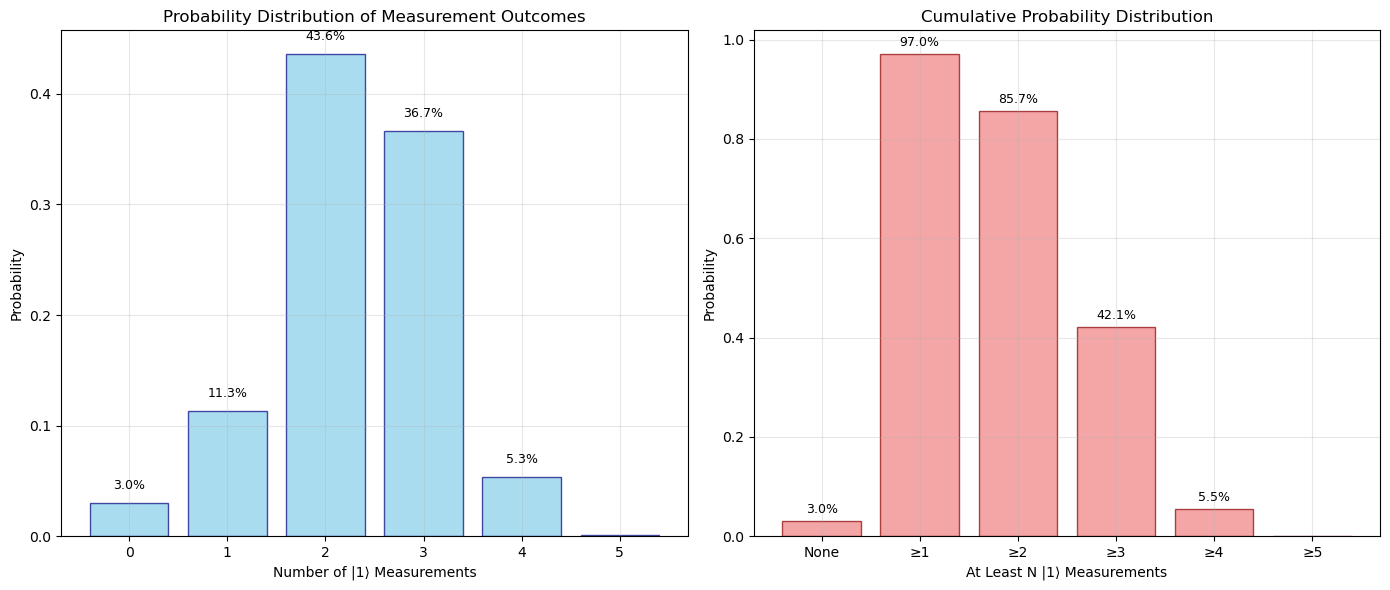


Detailed Analysis of Individual Sequences:
Sequence	Outcomes	Probability	Description
------------------------------------------------------------
00011	[0, 0, 0, 1, 1]	   43.56%	2 detection(s)
00111	[0, 0, 1, 1, 1]	   36.67%	3 detection(s)
00001	[0, 0, 0, 0, 1]	    8.88%	1 detection(s)
01111	[0, 1, 1, 1, 1]	    5.34%	4 detection(s)
00000	[0, 0, 0, 0, 0]	    2.98%	All |0⟩ (no detections)
00100	[0, 0, 1, 0, 0]	    1.35%	1 detection(s)
00010	[0, 0, 0, 1, 0]	    0.74%	1 detection(s)
01000	[0, 1, 0, 0, 0]	    0.33%	1 detection(s)
11111	[1, 1, 1, 1, 1]	    0.13%	All |1⟩ (all detections)
10000	[1, 0, 0, 0, 0]	    0.01%	1 detection(s)

... and 22 more sequences

SUMMARY STATISTICS:
Most probable sequence: 00011 (43.56%)
Least probable sequence: 01110 (-0.00%)
Average detection probability: 19.40%
Total probability (normalization check): 100.00%

Simulation completed successfully!
All 32 measurement sequences analyzed and visualized.


In [3]:
# STATISTICAL ANALYSIS OF MEASUREMENT OUTCOMES

# ==================== PROBABILITY DISTRIBUTION ANALYSIS ====================
# Calculate probability distribution for different numbers of |1⟩ measurements

# Initialize probability sums for each possible number of |1⟩ outcomes
prob_sums = np.zeros(nmeas + 1)

print("=" * 60)
print("STATISTICAL ANALYSIS OF MEASUREMENT SEQUENCES")
print("=" * 60)

# Process each measurement sequence
for sequence_idx in measurement_sequences:
    # Convert sequence to binary and count |1⟩ outcomes
    binary_str = format(sequence_idx, f'0{nmeas}b')
    measurement_outcomes = [int(bit) for bit in binary_str]
    num_ones = np.sum(measurement_outcomes)
    
    # Add probability to corresponding sum
    prob_sums[num_ones] += sequence_probabilities[sequence_idx]

# Calculate cumulative probabilities (at least N detections)
cumulative_probs = 1 - np.cumsum(prob_sums)

# ==================== RESULTS DISPLAY ====================
print(f"\nMeasurement Statistics:")
print(f"Total number of sequences: {total_sequences}")
print(f"Number of measurement intervals: {nmeas}")
print(f"Time intervals: {[f'{t:.2f}' for t in tint]}")

print(f"\nProbability Distribution:")
print("Number of |1⟩ measurements\tProbability")
print("-" * 45)
for i in range(nmeas + 1):
    print(f"{i:^23d}\t{100*prob_sums[i]:>8.2f}%")

print(f"\nCumulative Probabilities:")
print("At least N |1⟩ measurements\tProbability")
print("-" * 45)
print(f"{'None (all |0⟩)':^24s}\t{100*sequence_probabilities[0]:>8.2f}%")
for i in range(nmeas):
    print(f"{i+1:^24d}\t{100*cumulative_probs[i]:>8.2f}%")

# ==================== VISUALIZATION OF STATISTICS ====================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Probability distribution
x_vals = np.arange(nmeas + 1)
bars1 = ax1.bar(x_vals, prob_sums, alpha=0.7, color='skyblue', edgecolor='navy')
ax1.set_xlabel('Number of |1⟩ Measurements')
ax1.set_ylabel('Probability')
ax1.set_title('Probability Distribution of Measurement Outcomes')
ax1.set_xticks(x_vals)
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars1):
    height = bar.get_height()
    if height > 0.01:  # Only show labels for significant probabilities
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{100*height:.1f}%', ha='center', va='bottom', fontsize=9)

# Plot 2: Cumulative probabilities
cumulative_data = [sequence_probabilities[0]] + list(cumulative_probs[:-1])
labels = ['None'] + [f'≥{i+1}' for i in range(nmeas)]
bars2 = ax2.bar(range(len(cumulative_data)), cumulative_data, 
                alpha=0.7, color='lightcoral', edgecolor='darkred')
ax2.set_xlabel('At Least N |1⟩ Measurements')
ax2.set_ylabel('Probability')
ax2.set_title('Cumulative Probability Distribution')
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels)
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars2):
    height = bar.get_height()
    if height > 0.01:  # Only show labels for significant probabilities
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{100*height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ==================== DETAILED SEQUENCE ANALYSIS ====================
print(f"\nDetailed Analysis of Individual Sequences:")
print("=" * 60)
print("Sequence\tOutcomes\tProbability\tDescription")
print("-" * 60)

# Sort sequences by probability (descending)
sorted_indices = np.argsort(sequence_probabilities)[::-1]

for i, seq_idx in enumerate(sorted_indices):
    binary_str = format(seq_idx, f'0{nmeas}b')
    prob = sequence_probabilities[seq_idx]
    outcomes = [int(bit) for bit in binary_str]
    
    # Create description
    if np.sum(outcomes) == 0:
        description = "All |0⟩ (no detections)"
    elif np.sum(outcomes) == nmeas:
        description = "All |1⟩ (all detections)"
    else:
        description = f"{np.sum(outcomes)} detection(s)"
    
    print(f"{binary_str}\t{outcomes}\t{100*prob:>8.2f}%\t{description}")
    
    # Show only top 10 most probable sequences
    if i >= 9:
        break

print(f"\n... and {total_sequences-10} more sequences")

# ==================== SUMMARY STATISTICS ====================
print(f"\nSUMMARY STATISTICS:")
print("=" * 30)
print(f"Most probable sequence: {format(sorted_indices[0], f'0{nmeas}b')} "
      f"({100*sequence_probabilities[sorted_indices[0]]:.2f}%)")
print(f"Least probable sequence: {format(sorted_indices[-1], f'0{nmeas}b')} "
      f"({100*sequence_probabilities[sorted_indices[-1]]:.2f}%)")
print(f"Average detection probability: {100*np.mean(prob_sums[1:]):.2f}%")
print(f"Total probability (normalization check): {100*np.sum(prob_sums):.2f}%")

print(f"\nSimulation completed successfully!")
print(f"All {total_sequences} measurement sequences analyzed and visualized.")